<a href="https://colab.research.google.com/github/honestfarmer-cod/avcad/blob/main/EXE07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Adjust the path to where the file actually is
path = "/content/sample_data/EFIplus_medit.zip"
df = pd.read_csv(path, compression="zip", sep=";")

df2 = df.dropna().copy()
df2.columns = list(map(str, df2.columns))

cont_vars = [
    "Altitude",
    "Actual_river_slope",
    "Elevation_mean_catch",
    "prec_ann_catch",
    "temp_ann",
    "temp_jan",
    "temp_jul"
]

Question 1): Visual check: which variables need transformation?

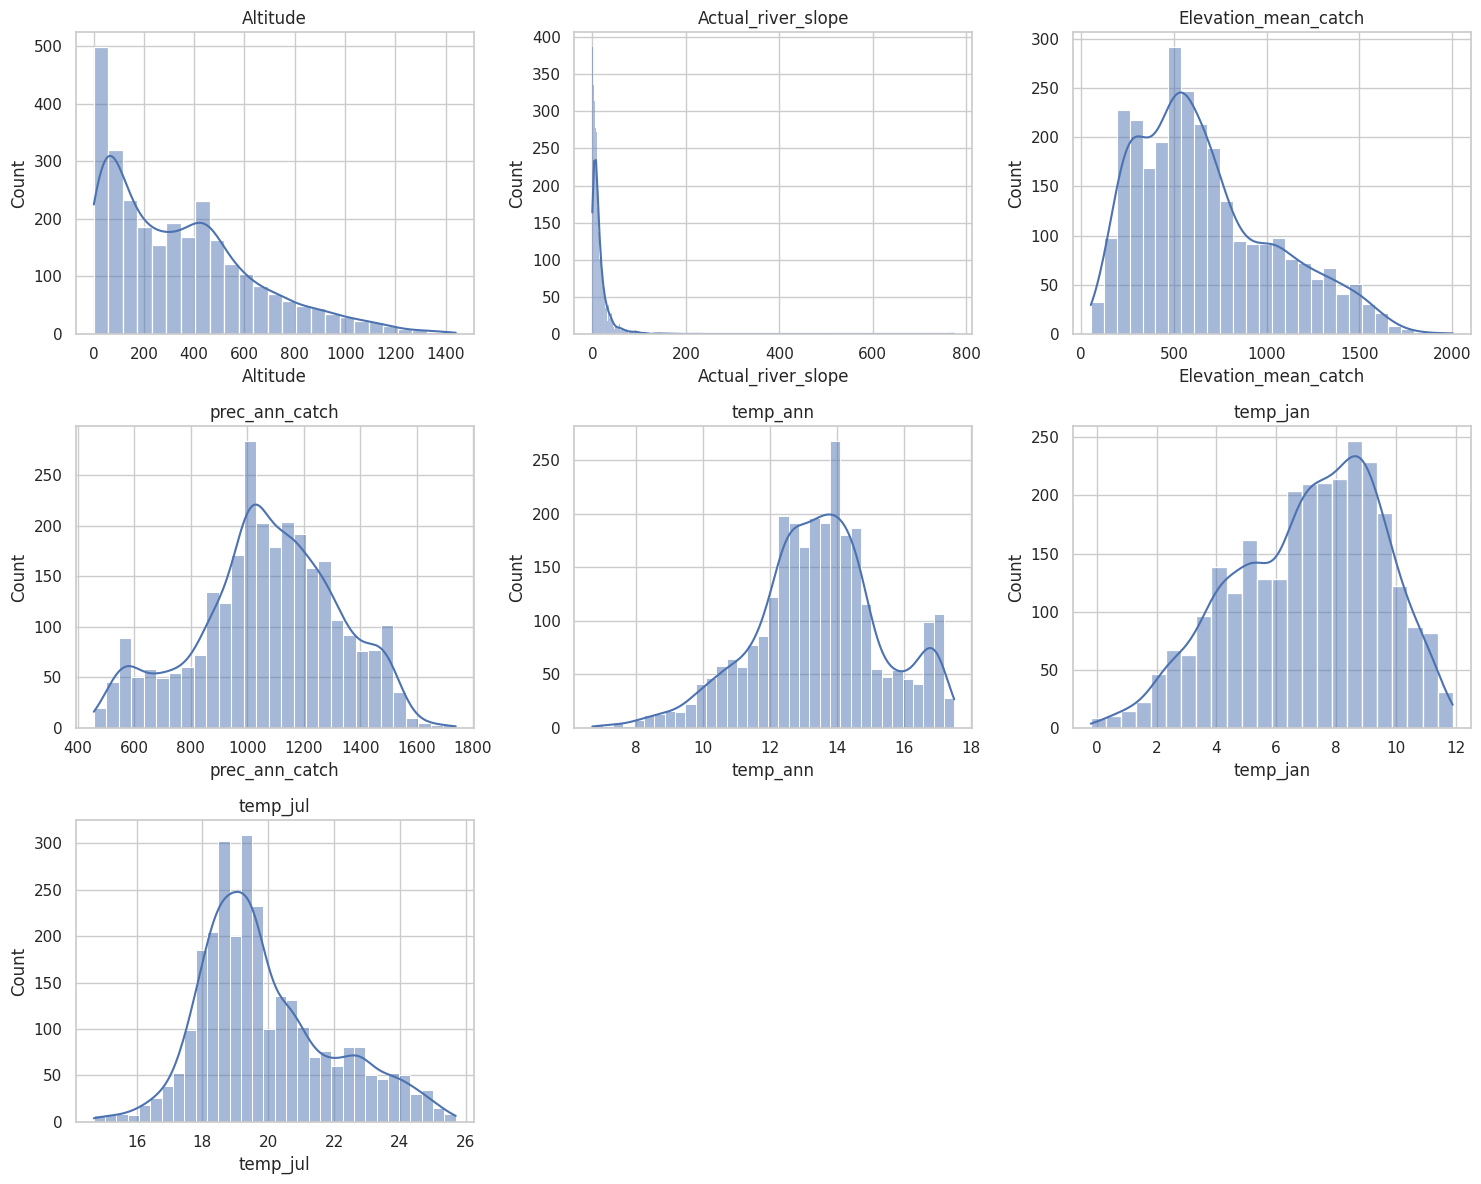

In [19]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for i, v in enumerate(cont_vars):
    sns.histplot(df2[v], kde=True, ax=axes[i])
    axes[i].set_title(v)

for j in range(len(cont_vars), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [20]:
from scipy import stats

rows = []
for v in cont_vars:
    s = df2[v].dropna()
    skew = s.skew()
    kurt = s.kurtosis()
    sample = s.sample(n=min(5000, len(s)), random_state=0)
    w, p = stats.shapiro(sample)
    rows.append([v, skew, kurt, w, p])

norm_df = pd.DataFrame(rows, columns=["var", "skew", "kurtosis", "W", "p"])
norm_df

,var,skew,kurtosis,W,p
0,Altitude,0.953840,0.460618,0.912241,1.264827e-37
1,Actual_river_slope,12.757115,350.891192,0.480204,1.039123e-67
2,Elevation_mean_catch,0.754099,-0.133949,0.943028,1.098154e-31
3,prec_ann_catch,-0.259466,-0.333764,0.984462,4.866595e-17
4,temp_ann,-0.213197,0.163878,0.985713,2.939042e-16
5,temp_jan,-0.403498,-0.519050,0.977567,1.084246e-20
6,temp_jul,0.638116,-0.014335,0.956105,2.326362e-28


Answer:Histograms and Shapiro tests showed strong positive skew for Actual_river_slope, prec_ann_catch and Altitude, while temperature variables were closer to symmetric distributions.

Question 2):Apply log transforms and re‑check

In [21]:
df2_trans = df2.copy()

log_vars = ["Actual_river_slope", "prec_ann_catch", "Altitude"]
for v in log_vars:
    # make sure no negatives
    df2_trans[v + "_log"] = np.log1p(df2_trans[v].clip(lower=0))

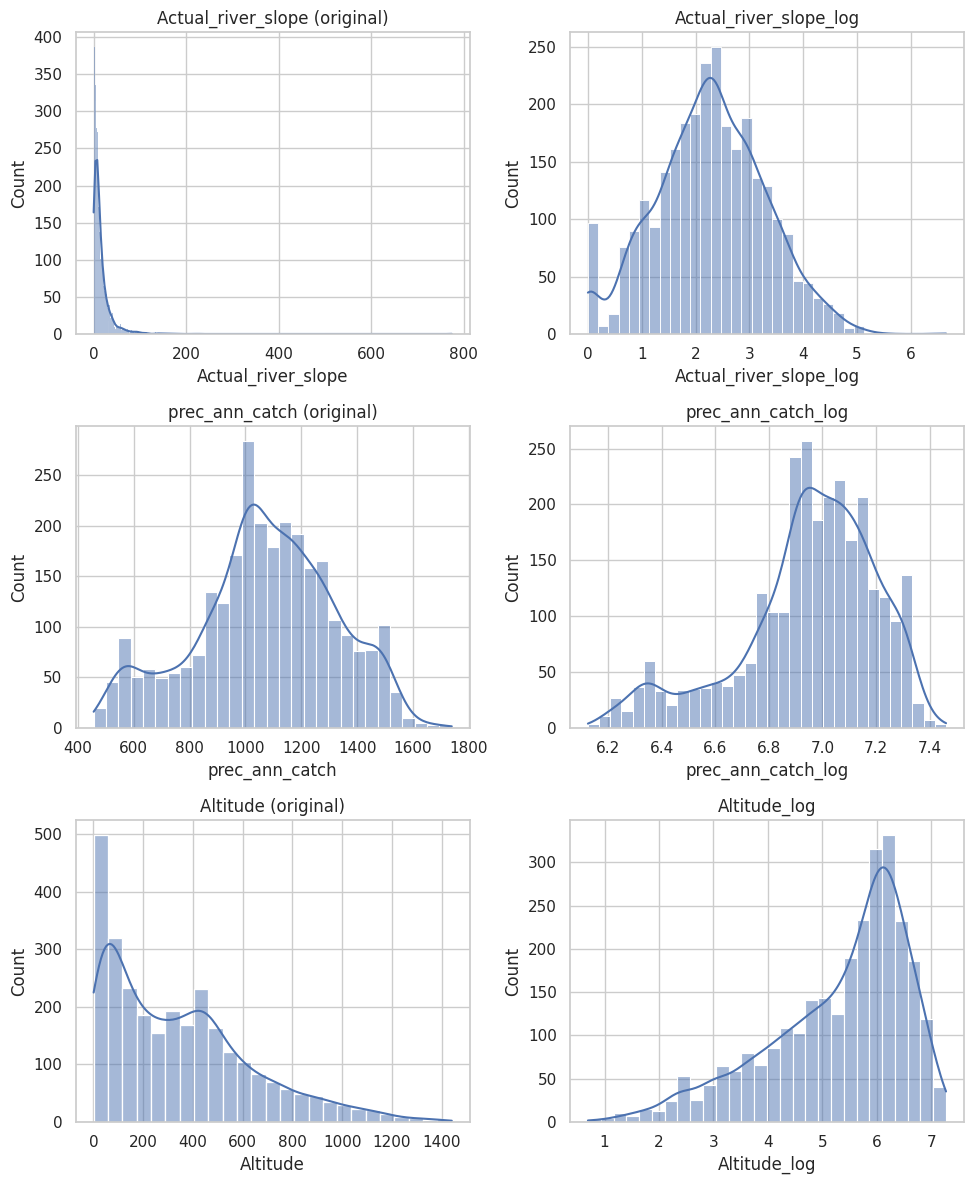

In [22]:
to_plot = log_vars  # originals

fig, axes = plt.subplots(len(to_plot), 2, figsize=(10, 4 * len(to_plot)))

for i, v in enumerate(to_plot):
    sns.histplot(df2[v], kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(v + " (original)")

    sns.histplot(df2_trans[v + "_log"], kde=True, ax=axes[i, 1])
    axes[i, 1].set_title(v + "_log")

plt.tight_layout()
plt.show()

Answer: The log transformation was applied to the skewed variables. After transformation, their histograms appeared more symmetric with reduced tails, making them more suitable for parametric tests.

Question 3):Species richness column

In [23]:
first_species = "Abramis brama"
start_idx = df2.columns.get_loc(first_species)
species_cols = df2.columns[start_idx:]

# assure binary 0/1
df2[species_cols] = (df2[species_cols] > 0).astype(int)

df2["species_richness"] = df2[species_cols].sum(axis=1)
df2_trans["species_richness"] = df2["species_richness"]

df2["species_richness"].describe()

/tmp/ipykernel_59932/437639839.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df2["species_richness"] = df2[species_cols].sum(axis=1)


,species_richness
count,2822.000000
mean,3.418143
std,2.432979
min,0.000000
25%,1.000000
50%,3.000000
75%,5.000000
max,14.000000


Answer:Species richness was computed as the sum of all species presence/absence columns from “Abramis brama” to the last species column, giving the number of species per sampling site.

Question 4): Bivariate outliers: temp_ann vs species richness

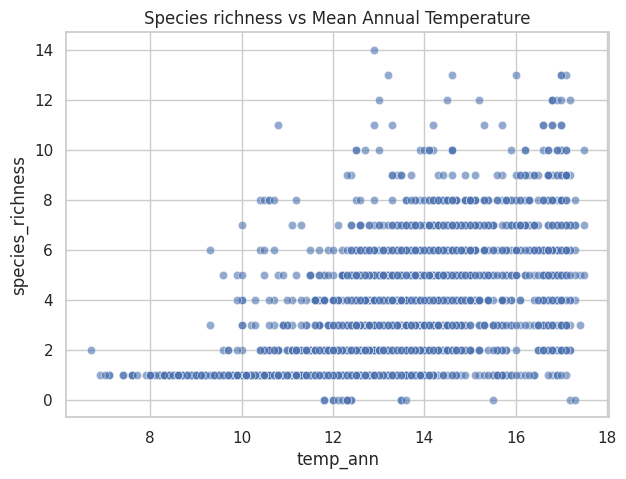

In [24]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df2, x="temp_ann", y="species_richness", alpha=0.6)
plt.title("Species richness vs Mean Annual Temperature")
plt.show()

In [25]:
from sklearn.ensemble import IsolationForest

X = df2[["temp_ann", "species_richness"]].dropna().copy()

iso = IsolationForest(
    contamination=0.02,  # ~2% as potential outliers
    random_state=0
)
labels = iso.fit_predict(X)  # 1=inlier, -1=outlier
X["outlier_flag"] = labels

X["outlier_flag"].value_counts()

,count
outlier_flag,
1,2765
-1,57


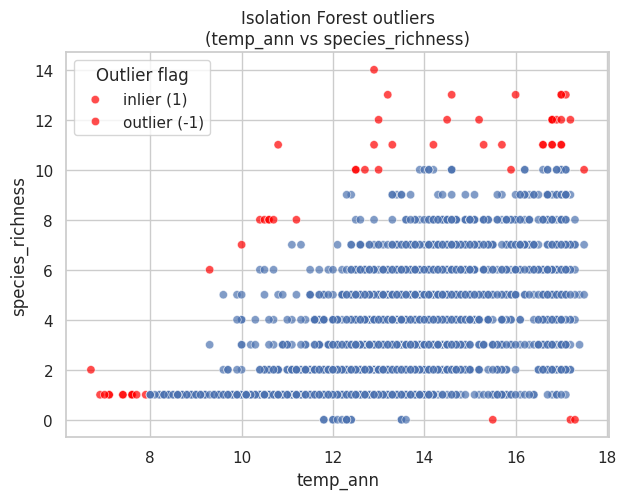

In [26]:
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=X,
    x="temp_ann",
    y="species_richness",
    hue="outlier_flag",
    palette={1: "C0", -1: "red"},
    alpha=0.7
)
plt.title("Isolation Forest outliers\n(temp_ann vs species_richness)")
plt.legend(title="Outlier flag", labels=["inlier (1)", "outlier (-1)"])
plt.show()

##Answer:The scatterplot of temp_ann vs species richness showed a few isolated points. A bivariate Isolation Forest (using temp_ann and species richness) classified approximately 2% of observations as outliers, which correspond to extreme richness values at unusual temperatures.

Question 5):Does temp_ann–richness relationship vary across countries?

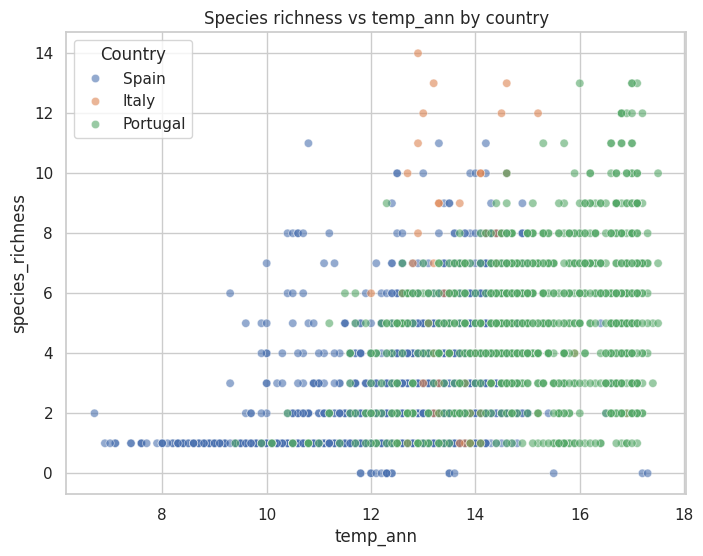

In [27]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df2,
    x="temp_ann",
    y="species_richness",
    hue="Country",
    alpha=0.6
)
plt.title("Species richness vs temp_ann by country")
plt.show()

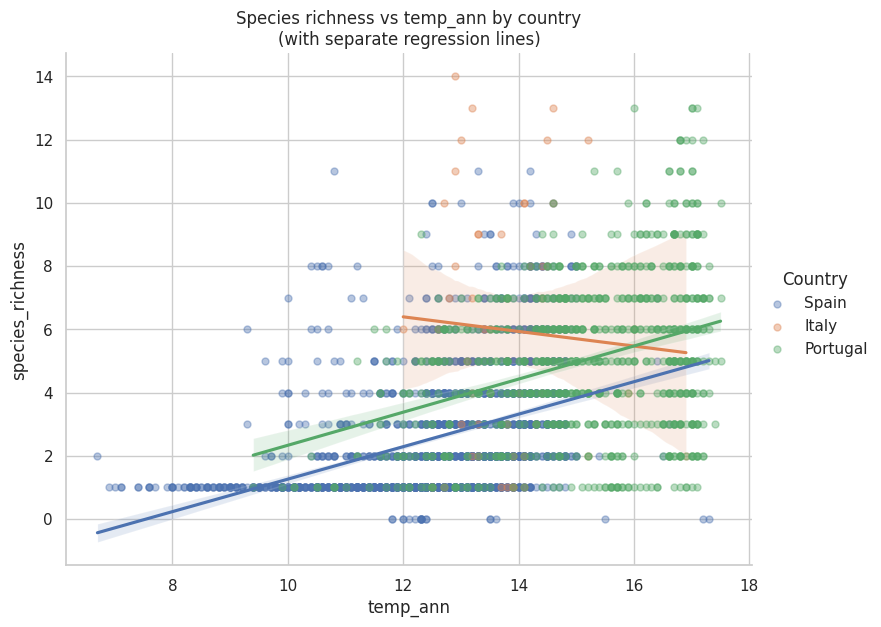

In [28]:
sns.lmplot(
    data=df2,
    x="temp_ann",
    y="species_richness",
    hue="Country",
    scatter_kws={"alpha": 0.4, "s": 25},
    height=6,
    aspect=1.3
)
plt.title("Species richness vs temp_ann by country\n(with separate regression lines)")
plt.show()

#Answer:A coloured scatterplot and lmplot by Country indicated that the slope and dispersion of the temp_ann–richness relationship differ between countries (you specify: e.g. some countries show increasing richness with temperature, others flatter or different ranges).